In [17]:
import matplotlib.pyplot as plt
import numpy as np

In [26]:
SAMPLE_RATE = 1000
FREQUENCY = 10.0
PI_OVER_4 = np.pi / 4.0
TWO_PI = np.pi * 2.0

In [27]:
class Oscillator:
    def __init__(self):
        self.period = SAMPLE_RATE / FREQUENCY
        self.amplitude = 1.0
        self.phase = 0.0
        self.phase_max = TWO_PI
        self.inc = FREQUENCY / SAMPLE_RATE

    def reset(self):
        self.inc = 0.0
        self.phase = 0.0

    def next_sample(self):
        output = 0.0
        self.phase += self.inc

        if self.phase <= PI_OVER_4:
            half_period = self.period / 2.0
            self.phase_max = np.floor(0.5 + half_period) - 0.5
            self.phase_max *= np.pi
            self.inc = self.phase_max / half_period
            self.phase = -self.phase

            if np.square(self.phase) > 1e-9:
                output = self.amplitude * np.sin(self.phase) / self.phase
            else:
                output = self.amplitude
        
        else:
            if self.phase > self.phase_max:
                self.phase = self.phase_max + self.phase_max - self.phase
                self.inc = -self.inc
            output = self.amplitude * np.sin(self.phase) / self.phase

        return output

In [28]:
buffer_size = 1000
buffer = np.empty(buffer_size, dtype=np.float32)
osc = Oscillator()
next_sample = osc.next_sample

for i in range(buffer_size):
    buffer[i] = next_sample()

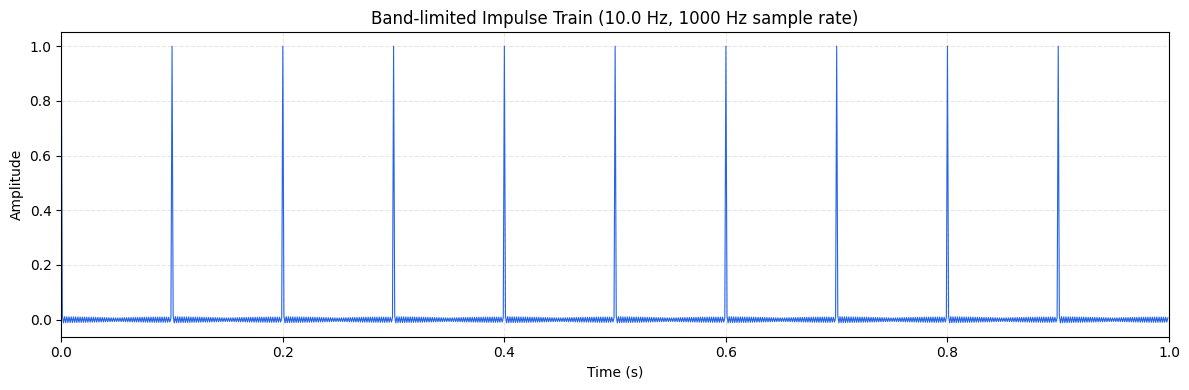

In [29]:
fig, ax = plt.subplots(figsize=(12, 4))

t = np.arange(buffer_size) / SAMPLE_RATE
ax.plot(t, buffer, linewidth=0.8, color="#2563eb")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Band-limited Impulse Train ({FREQUENCY} Hz, {SAMPLE_RATE} Hz sample rate)")
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim(0, buffer_size / SAMPLE_RATE)

fig.tight_layout()
plt.show()